In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_csv('ihdp_data.csv')

In [3]:
T = df['treatment'].astype(int)

In [4]:
df

,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,True,5.599916,4.318780,3.268256,6.854457,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,1,1,0,0,0,0,0,0
1,False,6.875856,7.856495,6.636059,7.562718,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,1,1,0,0,0,0,0,0
2,False,2.996273,6.633952,1.570536,6.121617,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,0,1,1,0,0,0,0,0,0
3,False,1.366206,5.697239,1.244738,5.889125,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,0,1,1,0,0,0,0,0,0
4,False,1.963538,6.202582,1.685048,6.191994,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,False,4.091946,6.061976,3.986826,7.053195,-0.007654,-0.202946,-0.360898,0.161703,-0.316603,...,1,0,1,0,0,0,0,0,0,0
743,True,5.501677,4.237157,4.111877,7.084080,0.727295,-0.202946,-0.733261,-0.879606,0.808706,...,1,1,1,0,0,0,0,0,0,0
744,False,1.842583,4.949537,2.346736,6.523225,1.181234,0.196818,-1.477987,0.161703,0.746189,...,1,1,1,0,0,0,0,0,0,0
745,False,3.076368,7.554212,2.114661,6.419095,-0.288664,-0.202946,-1.477987,-0.879606,1.621430,...,1,1,1,0,0,0,0,0,0,0


In [5]:
df.shape

(747, 30)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 747 entries, 0 to 746
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   treatment   747 non-null    bool   
 1   y_factual   747 non-null    float64
 2   y_cfactual  747 non-null    float64
 3   mu0         747 non-null    float64
 4   mu1         747 non-null    float64
 5   x1          747 non-null    float64
 6   x2          747 non-null    float64
 7   x3          747 non-null    float64
 8   x4          747 non-null    float64
 9   x5          747 non-null    float64
 10  x6          747 non-null    float64
 11  x7          747 non-null    int64  
 12  x8          747 non-null    int64  
 13  x9          747 non-null    int64  
 14  x10         747 non-null    int64  
 15  x11         747 non-null    int64  
 16  x12         747 non-null    int64  
 17  x13         747 non-null    int64  
 18  x14         747 non-null    int64  
 19  x15         747 non-null    int64  
 20 

In [7]:
df["treatment"].value_counts()

treatment
False    608
True     139
Name: count, dtype: int64

In [8]:
Y = df["y_factual"]

In [9]:
Y

0      5.599916
1      6.875856
2      2.996273
3      1.366206
4      1.963538
         ...   
742    4.091946
743    5.501677
744    1.842583
745    3.076368
746    2.928105
Name: y_factual, Length: 747, dtype: float64

In [10]:
df["true_ite"] = df["mu1"] - df["mu0"]

In [11]:
df[["treatment", "mu0", "mu1", "true_ite"]]

,treatment,mu0,mu1,true_ite
0,True,3.268256,6.854457,3.586200
1,False,6.636059,7.562718,0.926659
2,False,1.570536,6.121617,4.551081
3,False,1.244738,5.889125,4.644387
4,False,1.685048,6.191994,4.506946
...,...,...,...,...
742,False,3.986826,7.053195,3.066370
743,True,4.111877,7.084080,2.972203
744,False,2.346736,6.523225,4.176489
745,False,2.114661,6.419095,4.304433


In [12]:
X = df[[f"x{i}" for i in range(1, 26)]]

In [13]:
X

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,x16,x17,x18,x19,x20,x21,x22,x23,x24,x25
0,-0.528603,-0.343455,1.128554,0.161703,-0.316603,1.295216,1,0,1,0,...,1,1,1,1,0,0,0,0,0,0
1,-1.736945,-1.802002,0.383828,2.244320,-0.629189,1.295216,0,0,0,1,...,1,1,1,1,0,0,0,0,0,0
2,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,-0.526556,0,0,0,1,...,1,0,1,1,0,0,0,0,0,0
3,0.390083,0.596582,-1.850350,-0.879606,-0.004017,-0.857787,0,0,0,0,...,1,0,1,1,0,0,0,0,0,0
4,-1.045229,-0.602710,0.011465,0.161703,0.683672,-0.360940,1,0,0,0,...,1,1,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,-0.007654,-0.202946,-0.360898,0.161703,-0.316603,1.792063,0,0,1,0,...,1,0,1,0,0,0,0,0,0,0
743,0.727295,-0.202946,-0.733261,-0.879606,0.808706,1.129600,0,0,1,0,...,1,1,1,0,0,0,0,0,0,0
744,1.181234,0.196818,-1.477987,0.161703,0.746189,0.467138,0,0,0,0,...,1,1,1,0,0,0,0,0,0,0
745,-0.288664,-0.202946,-1.477987,-0.879606,1.621430,0.467138,1,0,1,0,...,1,1,1,0,0,0,0,0,0,0


In [14]:
## verification

print("Dataset shape:", df.shape)
print("X shape:", X.shape)
print("Treatment shape:", T.shape)
print("Outcome shape:", Y.shape)
print("True ITE shape:", df['true_ite'].shape)

Dataset shape: (747, 31)
X shape: (747, 25)
Treatment shape: (747,)
Outcome shape: (747,)
True ITE shape: (747,)


In [15]:
treated_mean = Y[T == 1].mean()
control_mean = Y[T == 0].mean()

naive_ate = treated_mean - control_mean

print("Treated mean:", treated_mean)
print("Control mean:", control_mean)
print("Naive ATE:", naive_ate)

Treated mean: 6.432417812422448
Control mean: 2.4112967999916193
Naive ATE: 4.021121012430829


In [16]:
true_ate = df["true_ite"].mean()

print("True ATE:", true_ate)

True ATE: 4.016066896118338


In [17]:
print("Naive ATE:", naive_ate)
print("True ATE:", true_ate)
print("Bias:", naive_ate - true_ate)

Naive ATE: 4.021121012430829
True ATE: 4.016066896118338
Bias: 0.005054116312490642


In [18]:
X = df[[f"x{i}" for i in range(1, 26)]]

print(X.shape)

(747, 25)


In [19]:
from sklearn.linear_model import LogisticRegression

In [20]:
ps_model = LogisticRegression(max_iter=1000)

ps_model.fit(X, T)

propensity_score = ps_model.predict_proba(X)[:, 1]

df["propensity_score"] = propensity_score

In [21]:
df

,treatment,y_factual,y_cfactual,mu0,mu1,x1,x2,x3,x4,x5,...,x18,x19,x20,x21,x22,x23,x24,x25,true_ite,propensity_score
0,True,5.599916,4.318780,3.268256,6.854457,-0.528603,-0.343455,1.128554,0.161703,-0.316603,...,1,1,0,0,0,0,0,0,3.586200,0.283505
1,False,6.875856,7.856495,6.636059,7.562718,-1.736945,-1.802002,0.383828,2.244320,-0.629189,...,1,1,0,0,0,0,0,0,0.926659,0.068051
2,False,2.996273,6.633952,1.570536,6.121617,-0.807451,-0.202946,-0.360898,-0.879606,0.808706,...,1,1,0,0,0,0,0,0,4.551081,0.107717
3,False,1.366206,5.697239,1.244738,5.889125,0.390083,0.596582,-1.850350,-0.879606,-0.004017,...,1,1,0,0,0,0,0,0,4.644387,0.129523
4,False,1.963538,6.202582,1.685048,6.191994,-1.045229,-0.602710,0.011465,0.161703,0.683672,...,1,1,0,0,0,0,0,0,4.506946,0.092541
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
742,False,4.091946,6.061976,3.986826,7.053195,-0.007654,-0.202946,-0.360898,0.161703,-0.316603,...,1,0,0,0,0,0,0,0,3.066370,0.241466
743,True,5.501677,4.237157,4.111877,7.084080,0.727295,-0.202946,-0.733261,-0.879606,0.808706,...,1,0,0,0,0,0,0,0,2.972203,0.336693
744,False,1.842583,4.949537,2.346736,6.523225,1.181234,0.196818,-1.477987,0.161703,0.746189,...,1,0,0,0,0,0,0,0,4.176489,0.163558
745,False,3.076368,7.554212,2.114661,6.419095,-0.288664,-0.202946,-1.477987,-0.879606,1.621430,...,1,0,0,0,0,0,0,0,4.304433,0.248661


In [22]:
print(df["propensity_score"].describe())

count    747.000000
mean       0.186071
std        0.122632
min        0.015280
25%        0.083007
50%        0.151565
75%        0.267657
max        0.596300
Name: propensity_score, dtype: float64


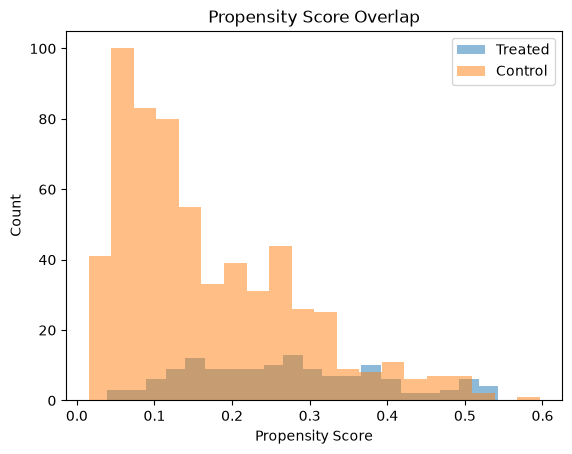

In [23]:
import matplotlib.pyplot as plt

plt.hist(
    df.loc[T == 1, "propensity_score"],
    bins=20,
    alpha=0.5,
    label="Treated"
)

plt.hist(
    df.loc[T == 0, "propensity_score"],
    bins=20,
    alpha=0.5,
    label="Control"
)

plt.xlabel("Propensity Score")
plt.ylabel("Count")
plt.title("Propensity Score Overlap")
plt.legend()
plt.show()

In [24]:
from sklearn.neighbors import NearestNeighbors

treated = df[df["treatment"] == 1].copy()
control = df[df["treatment"] == 0].copy()

nn = NearestNeighbors(n_neighbors=1)

nn.fit(control[["propensity_score"]])

distances, indices = nn.kneighbors(
    treated[["propensity_score"]]
)

matched_control = control.iloc[indices.flatten()].copy()

In [25]:
matched_ate = (
    treated["y_factual"].values -
    matched_control["y_factual"].values
).mean()

print("Naive ATE:", naive_ate)
print("True ATE:", true_ate)
print("Matched ATE:", matched_ate)

Naive ATE: 4.021121012430829
True ATE: 4.016066896118338
Matched ATE: 3.7768352642503777


In [26]:
matched_bias = matched_ate - true_ate

print("Naive Bias:", naive_ate - true_ate)
print("Matched Bias:", matched_bias)

Naive Bias: 0.005054116312490642
Matched Bias: -0.23923163186796037


In [31]:
from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [32]:
causal_forest = CausalForestDML(
    model_y=RandomForestRegressor(
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42
    ),
    model_t=LogisticRegression(max_iter=1000),
    discrete_treatment=True,
    random_state=42
)

In [33]:
causal_forest.fit(
    Y,
    T,
    X=X
)

In [34]:
estimated_ite = causal_forest.effect(X)

df["estimated_ite"] = estimated_ite

print(df[["true_ite", "estimated_ite"]].head())

   true_ite  estimated_ite
0  3.586200       3.200943
1  0.926659       1.761444
2  4.551081       4.228332
3  4.644387       4.316622
4  4.506946       4.256794


In [35]:
causal_forest_ate = df["estimated_ite"].mean()

print("True ATE:", true_ate)
print("Causal Forest ATE:", causal_forest_ate)

True ATE: 4.016066896118338
Causal Forest ATE: 3.775719900070317


In [36]:
cf_bias = causal_forest_ate - true_ate

print("Causal Forest Bias:", cf_bias)

Causal Forest Bias: -0.24034699604802112


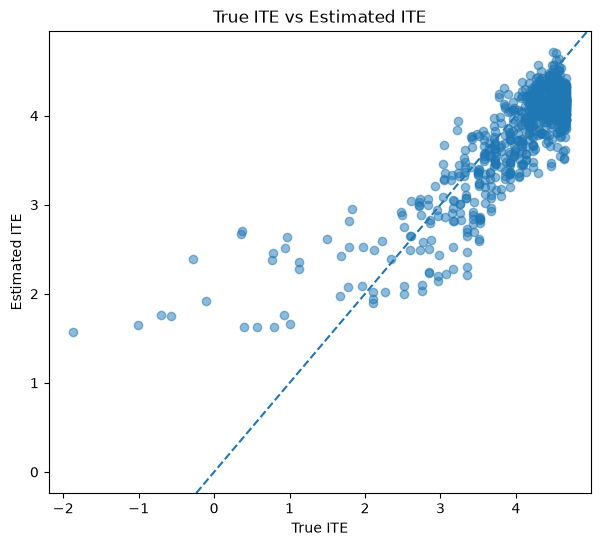

In [37]:
plt.figure(figsize=(7, 6))

plt.scatter(
    df["true_ite"],
    df["estimated_ite"],
    alpha=0.5
)

plt.xlabel("True ITE")
plt.ylabel("Estimated ITE")
plt.title("True ITE vs Estimated ITE")

plt.axline(
    (0, 0),
    slope=1,
    linestyle="--"
)

plt.show()

In [38]:
from sklearn.metrics import mean_squared_error
import numpy as np

ite_rmse = np.sqrt(
    mean_squared_error(
        df["true_ite"],
        df["estimated_ite"]
    )
)

print("ITE RMSE:", ite_rmse)

ITE RMSE: 0.5264678495430093


In [39]:
ite_correlation = df["true_ite"].corr(
    df["estimated_ite"]
)

print("ITE Correlation:", ite_correlation)

ITE Correlation: 0.8516261602553059


In [40]:
results = pd.DataFrame({
    "Method": [
        "Naive",
        "Propensity Matching",
        "Causal Forest"
    ],
    "ATE": [
        naive_ate,
        matched_ate,
        causal_forest_ate
    ],
    "Bias": [
        naive_ate - true_ate,
        matched_ate - true_ate,
        causal_forest_ate - true_ate
    ]
})

print(results)

                Method       ATE      Bias
0                Naive  4.021121  0.005054
1  Propensity Matching  3.776835 -0.239232
2        Causal Forest  3.775720 -0.240347
